# Regresión Logística -- mal porque no hice validación

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.impute import SimpleImputer


In [50]:
# read the data

df_entrena = pd.read_csv('data/hoteles-entrena.csv')
df_prueba = pd.read_csv('data/hoteles-prueba.csv')

# print the first rows of the dataframe
print(df_entrena.head())
print(df_prueba.head())

          hotel  lead_time  stays_in_weekend_nights  stays_in_week_nights  \
0  Resort_Hotel        342                        0                     0   
1  Resort_Hotel        737                        0                     0   
2  Resort_Hotel          7                        0                     1   
3  Resort_Hotel         13                        0                     1   
4  Resort_Hotel         14                        0                     2   

   adults children meal country market_segment distribution_channel  ...  \
0       2     none   BB     PRT         Direct               Direct  ...   
1       2     none   BB     PRT         Direct               Direct  ...   
2       1     none   BB     GBR         Direct               Direct  ...   
3       1     none   BB     GBR      Corporate            Corporate  ...   
4       2     none   BB     GBR      Online_TA                TA/TO  ...   

   booking_changes  deposit_type  agent company days_in_waiting_list  \
0       

In [51]:
# Mostrar el porcentaje de valores nulos, ordenados de mayor a menor
print((df_entrena.isnull().sum() / len(df_entrena) * 100).sort_values(ascending=False))

##print(df_prueba["company"].unique())
print(df_prueba["agent"].unique())
# Eliminar las columnas con más del 50% de valores nulos (company = 92.56%, tal vez después agent= 16.31%)
df_entrena = df_entrena.drop(columns=['company'])

company                           92.565259
agent                             16.313395
country                            0.566241
hotel                              0.000000
reserved_room_type                 0.000000
total_of_special_requests          0.000000
required_car_parking_spaces        0.000000
average_daily_rate                 0.000000
customer_type                      0.000000
days_in_waiting_list               0.000000
deposit_type                       0.000000
booking_changes                    0.000000
assigned_room_type                 0.000000
previous_bookings_not_canceled     0.000000
lead_time                          0.000000
previous_cancellations             0.000000
is_repeated_guest                  0.000000
distribution_channel               0.000000
market_segment                     0.000000
meal                               0.000000
children                           0.000000
adults                             0.000000
stays_in_week_nights            

### Del EDA

In [52]:
# Convertir las fechas en el conjunto de entrenamiento y prueba
df_entrena["arrival_date"] = pd.to_datetime(df_entrena["arrival_date"])
df_prueba["arrival_date"] = pd.to_datetime(df_prueba["arrival_date"])

# Extraer el mes y el día de la semana de la columna de fecha en el conjunto de entrenamiento
df_entrena['arrival_month'] = df_entrena['arrival_date'].dt.month
df_entrena['arrival_dayofweek'] = df_entrena['arrival_date'].dt.dayofweek

# Extraer el mes y el día de la semana de la columna de fecha en el conjunto de prueba
df_prueba['arrival_month'] = df_prueba['arrival_date'].dt.month
df_prueba['arrival_dayofweek'] = df_prueba['arrival_date'].dt.dayofweek

# Función para obtener la estacionalidad según el mes
def get_season(month):
    if month in [12, 1, 2]:
        return 'Invierno'
    elif month in [3, 4, 5]:
        return 'Primavera'
    elif month in [6, 7, 8]:
        return 'Verano'
    else:
        return 'Otoño'

# Aplicar la función de estacionalidad en ambos conjuntos
df_entrena['season'] = df_entrena['arrival_month'].apply(get_season)
df_prueba['season'] = df_prueba['arrival_month'].apply(get_season)

# Convertir la estacionalidad en variables dummy en ambos conjuntos
df_entrena = pd.get_dummies(df_entrena, columns=['season'], drop_first=True)
df_prueba = pd.get_dummies(df_prueba, columns=['season'], drop_first=True)

# Asegurarse de que el conjunto de prueba tenga las mismas columnas que el conjunto de entrenamiento
df_prueba = df_prueba.reindex(columns=df_entrena.columns, fill_value=0)

# Verificar el resultado
print(df_entrena.head())
print(df_prueba.head())



          hotel  lead_time  stays_in_weekend_nights  stays_in_week_nights  \
0  Resort_Hotel        342                        0                     0   
1  Resort_Hotel        737                        0                     0   
2  Resort_Hotel          7                        0                     1   
3  Resort_Hotel         13                        0                     1   
4  Resort_Hotel         14                        0                     2   

   adults children meal country market_segment distribution_channel  ...  \
0       2     none   BB     PRT         Direct               Direct  ...   
1       2     none   BB     PRT         Direct               Direct  ...   
2       1     none   BB     GBR         Direct               Direct  ...   
3       1     none   BB     GBR      Corporate            Corporate  ...   
4       2     none   BB     GBR      Online_TA                TA/TO  ...   

   customer_type  average_daily_rate  required_car_parking_spaces  \
0      Tran

In [53]:
# Seleccionar las columnas categóricas que queremos convertir a variables dummy
categorical_columns = ['hotel', 'meal', 'market_segment', 'distribution_channel', 
                       'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']

# Convertir las columnas categóricas en variables dummy en ambos conjuntos (entrenamiento y prueba)
df_entrena = pd.get_dummies(df_entrena, columns=categorical_columns, drop_first=True)
df_prueba = pd.get_dummies(df_prueba, columns=categorical_columns, drop_first=True)

# Asegurarse de que df_prueba tenga las mismas columnas que df_entrena
df_prueba = df_prueba.reindex(columns=df_entrena.columns, fill_value=0)

In [54]:
# Verificar que ambas tablas tengan las mismas columnas y el mismo número de columnas
print(f"Columnas en df_entrena: {df_entrena.shape[1]}")
print(f"Columnas en df_prueba: {df_prueba.shape[1]}")

# Verificar las primeras filas de df_entrena y df_prueba
print(df_entrena.head())
print(df_prueba.head())


Columnas en df_entrena: 58
Columnas en df_prueba: 58
   lead_time  stays_in_weekend_nights  stays_in_week_nights  adults children  \
0        342                        0                     0       2     none   
1        737                        0                     0       2     none   
2          7                        0                     1       1     none   
3         13                        0                     1       1     none   
4         14                        0                     2       2     none   

  country  is_repeated_guest  previous_cancellations  \
0     PRT                  0                       0   
1     PRT                  0                       0   
2     GBR                  0                       0   
3     GBR                  0                       0   
4     GBR                  0                       0   

   previous_bookings_not_canceled  booking_changes  ...  assigned_room_type_F  \
0                               0               

In [55]:
# agregar variable de tiempo total de estancia
df_entrena['total_stay'] = df_entrena['stays_in_weekend_nights'] + df_entrena['stays_in_week_nights']
df_prueba['total_stay'] = df_prueba['stays_in_weekend_nights'] + df_prueba['stays_in_week_nights']



In [56]:
# Convertir los valores de 'children' en df_entrena a numéricos (0 y 1)
df_entrena['children'] = df_entrena['children'].map({'none': 0, 'children': 1})

# Verificar la conversión
print(df_entrena['children'].unique())  



[0 1]


In [57]:
# Ajustar la lista de columnas categóricas con las que están presentes en df_entrena
categorical_columns = ['country', 'hotel_Resort_Hotel', 'meal_FB', 'meal_HB', 'meal_SC', 'meal_Undefined', 
                       'market_segment_Complementary', 'market_segment_Corporate', 'market_segment_Direct', 
                       'market_segment_Groups', 'market_segment_Offline_TA/TO', 'market_segment_Online_TA', 
                       'distribution_channel_Direct', 'distribution_channel_GDS', 'distribution_channel_TA/TO', 
                       'distribution_channel_Undefined', 'reserved_room_type_B', 'reserved_room_type_C', 
                       'reserved_room_type_D', 'reserved_room_type_E', 'reserved_room_type_F', 'reserved_room_type_G', 
                       'reserved_room_type_H', 'reserved_room_type_L', 'assigned_room_type_B', 'assigned_room_type_C', 
                       'assigned_room_type_D', 'assigned_room_type_E', 'assigned_room_type_F', 'assigned_room_type_G', 
                       'assigned_room_type_H', 'assigned_room_type_I', 'assigned_room_type_K', 
                       'deposit_type_Non_Refund', 'deposit_type_Refundable', 'customer_type_Group', 
                       'customer_type_Transient', 'customer_type_Transient-Party']



In [58]:
# Mantener la columna 'id' y convertir las categóricas
df_entrena = pd.get_dummies(df_entrena, columns=categorical_columns, drop_first=True)
df_prueba = pd.get_dummies(df_prueba, columns=categorical_columns, drop_first=True)

# Asegurarte de que 'id' se mantenga en el conjunto de prueba y se alinee con el entrenamiento
df_prueba = df_prueba.reindex(columns=df_entrena.columns, fill_value=0)

# Asegurarte de que 'id' siga intacta
df_prueba['id'] = df_prueba.index if 'id' not in df_prueba.columns else df_prueba['id']



In [59]:
# Definir las características (X) y la variable objetivo (y)
X_train = df_entrena.drop(columns=['children'])  # Excluimos la columna objetivo 'children' del conjunto de entrenamiento
y_train = df_entrena['children']  # La columna objetivo que queremos predecir (0 o 1)

# Para el conjunto de prueba, solo necesitamos las características (X_test)
X_test = df_prueba.drop(columns=['children'], errors='ignore')  # Excluimos 'children' si está en el conjunto de prueba



In [60]:
# Volver a convertir las columnas categóricas restantes en variables dummy
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Asegurarse de que X_test tenga las mismas columnas que X_train
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)


In [61]:
# Eliminar las columnas de tipo datetime (como 'arrival_date')
X_train = X_train.drop(columns=['arrival_date'], errors='ignore')
X_test = X_test.drop(columns=['arrival_date'], errors='ignore')

# Verificar que todas las columnas ahora sean numéricas
print(X_train.dtypes.tolist())




[dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('float64'), dtype('int64'), dtype('float64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('uint8'), dtype('uint8'), dtype('uint8'), dtype('int64'), dtype('uint8'), dtype('uint8'), dtype('uint8'), dtype('uint8'), dtype('uint8'), dtype('uint8'), dtype('uint8'), dtype('uint8'), dtype('uint8'), dtype('uint8'), dtype('uint8'), dtype('uint8'), dtype('uint8'), dtype('uint8'), dtype('uint8'), dtype('uint8'), dtype('uint8'), dtype('uint8'), dtype('uint8'), dtype('uint8'), dtype('uint8'), dtype('uint8'), dtype('uint8'), dtype('uint8'), dtype('uint8'), dtype('uint8'), dtype('uint8'), dtype('uint8'), dtype('uint8'), dtype('uint8'), dtype('uint8'), dtype('uint8'), dtype('uint8'), dtype('uint8'), dtype('uint8'), dtype('uint8'), dtype('uint8'), dtype('uint8'), dtype('uint8'), dtype('uint8'), dtype('uint8'), dtype('uint8'), dtype('uint8'), dtype('uint8'), dty

In [62]:

# Crear un imputador que reemplace NaN con la mediana
imputer = SimpleImputer(strategy='median')

# Aplicar el imputador al conjunto de entrenamiento
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)


In [63]:
# Inicializar el escalador
scaler = StandardScaler()

# Escalar los datos de entrenamiento
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Volver a entrenar el modelo con los datos escalados
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=1000)

In [64]:
# Predecir probabilidades para el conjunto de prueba
y_test_probs = log_reg.predict_proba(X_test_scaled)[:, 1]

# Predecir clases (0 o 1)
y_test_pred = log_reg.predict(X_test_scaled)


In [65]:

# Verificar si 'id' está presente en ambos DataFrames
print("'id' en df_entrena:", 'id' in df_entrena.columns)
print("'id' en df_prueba:", 'id' in df_prueba.columns)

'id' en df_entrena: False
'id' en df_prueba: True


In [66]:
# Obtener las probabilidades de predicción para el conjunto de prueba
y_test_probs = log_reg.predict_proba(X_test_scaled)[:, 1]  # Probabilidad de que sea 1 (es decir, haya niños)

# Obtener las clases predichas (0 o 1)
y_test_pred = log_reg.predict(X_test_scaled)

# Crear un DataFrame de predicciones incluyendo el ID
predicciones = pd.DataFrame({
    'id': df_prueba['id'],         
    'children_prob': y_test_probs,  # Probabilidad de que haya niños
    'children_pred': y_test_pred    # Predicción binaria (0 o 1)
})

# Ver las primeras filas
print(predicciones.head())


   id  children_prob  children_pred
0   0       0.018783              0
1   1       0.034326              0
2   2       0.746318              1
3   3       0.040338              0
4   4       0.033355              0


### Métricas en entrenamiento

Exactitud (Accuracy) en Entrenamiento: 0.9363
AUC-ROC en Entrenamiento: 0.8816
Matriz de Confusión en Entrenamiento:
[[48048   599]
 [ 2778  1556]]
Reporte de Clasificación en Entrenamiento:

              precision    recall  f1-score   support

           0       0.95      0.99      0.97     48647
           1       0.72      0.36      0.48      4334

    accuracy                           0.94     52981
   macro avg       0.83      0.67      0.72     52981
weighted avg       0.93      0.94      0.93     52981



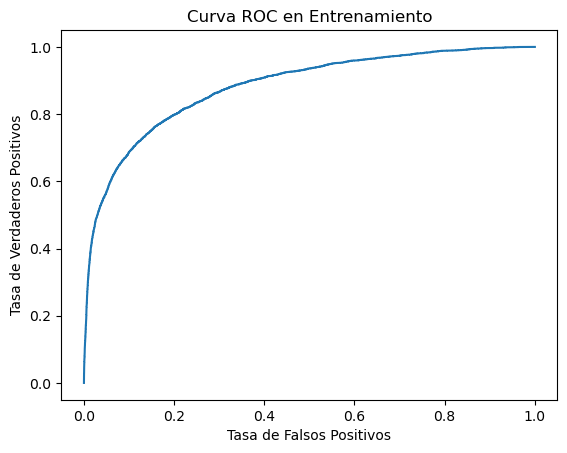

In [71]:
y_train_pred = log_reg.predict(X_train_scaled)
accuracy = accuracy_score(y_train, y_train_pred)
print(f"Exactitud (Accuracy) en Entrenamiento: {accuracy:.4f}")


y_train_probs = log_reg.predict_proba(X_train_scaled)[:, 1]  # Probabilidad de clase 1
auc_roc_train = roc_auc_score(y_train, y_train_probs)
print(f"AUC-ROC en Entrenamiento: {auc_roc_train:.4f}")

cm_train = confusion_matrix(y_train, y_train_pred)
print(f"Matriz de Confusión en Entrenamiento:\n{cm_train}")

print("Reporte de Clasificación en Entrenamiento:\n")
print(classification_report(y_train, y_train_pred))


fpr, tpr, thresholds = roc_curve(y_train, y_train_probs)
plt.plot(fpr, tpr, label='Curva ROC (Entrenamiento)')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC en Entrenamiento')
plt.show()

